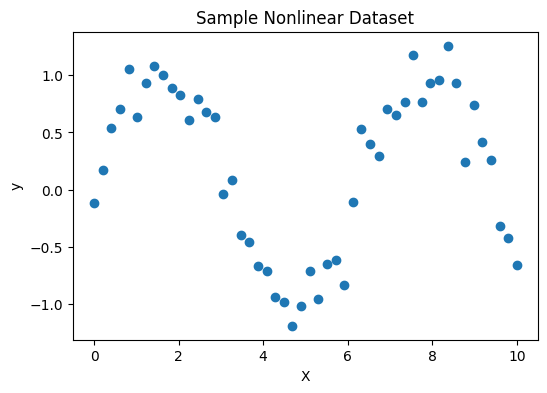

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a sample nonlinear dataset
X = np.linspace(0, 10, 50).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, 50)

X_plot = np.linspace(0, 10, 200).reshape(-1, 1)

plt.figure(figsize=(6, 4))
plt.scatter(X, y)
plt.title("Sample Nonlinear Dataset")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

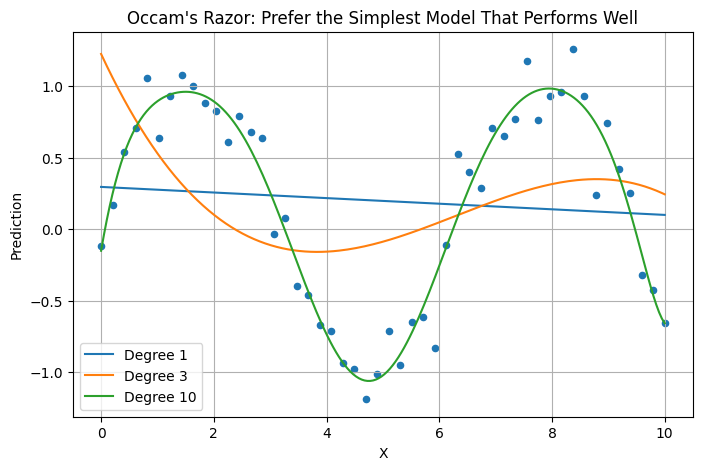

In [ ]:
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

degrees = [1, 3, 10]

plt.figure(figsize=(8, 5))
plt.scatter(X, y, s=20)

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X, y)
    plt.plot(X_plot, model.predict(X_plot), label=f"Degree {d}")

plt.title("Occam's Razor: Prefer the Simplest Model That Performs Well")
plt.xlabel("X")
plt.ylabel("Prediction")
plt.legend()
plt.grid(True)
plt.show()

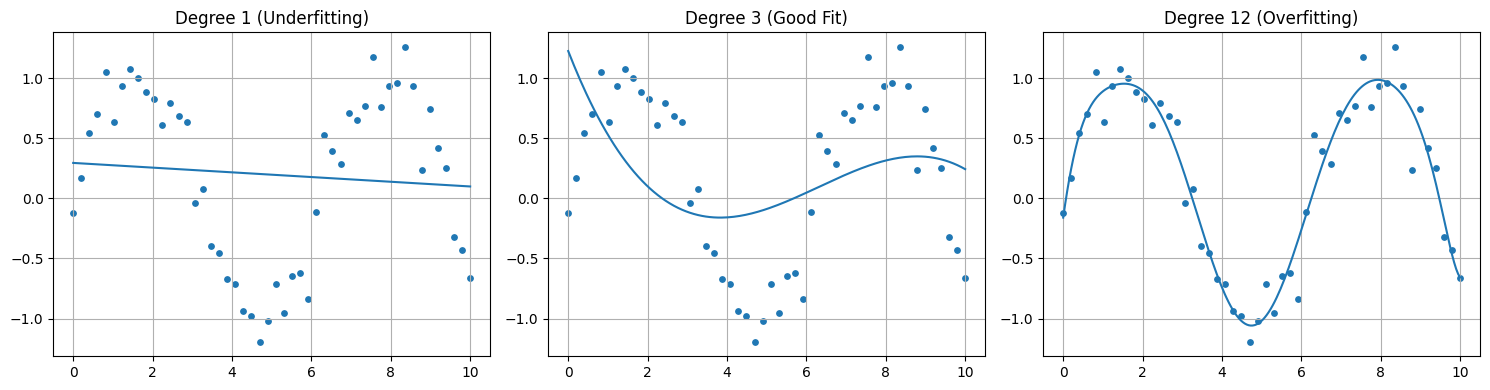

In [ ]:
models = [
    ("Degree 1 (Underfitting)", make_pipeline(PolynomialFeatures(1), LinearRegression())),
    ("Degree 3 (Good Fit)", make_pipeline(PolynomialFeatures(3), LinearRegression())),
    ("Degree 12 (Overfitting)", make_pipeline(PolynomialFeatures(12), LinearRegression()))
]

plt.figure(figsize=(15, 4))

for i, (title, model) in enumerate(models, 1):
    model.fit(X, y)
    plt.subplot(1, 3, i)
    plt.scatter(X, y, s=15)
    plt.plot(X_plot, model.predict(X_plot))
    plt.title(title)
    plt.grid(True)

plt.tight_layout()
plt.show()

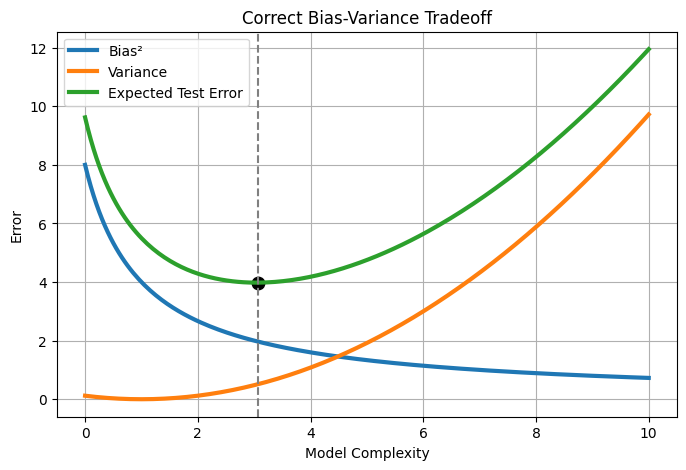

In [ ]:
complexity = np.linspace(0, 10, 200)
bias2 = 8 / (complexity + 1)
variance = 0.12 * (complexity - 1)**2
noise = np.ones_like(complexity) * 1.5
expected_test_error = bias2 + variance + noise

plt.figure(figsize=(8, 5))
plt.plot(complexity, bias2, label="Bias²", linewidth=3)
plt.plot(complexity, variance, label="Variance", linewidth=3)
plt.plot(complexity, expected_test_error, label="Expected Test Error", linewidth=3)

best = np.argmin(expected_test_error)
plt.scatter(complexity[best], expected_test_error[best], color="black", s=80)
plt.axvline(complexity[best], linestyle="--", color="gray")

plt.xlabel("Model Complexity")
plt.ylabel("Error")
plt.title("Correct Bias-Variance Tradeoff")
plt.legend()

plt.grid(True)
plt.show()